# Fermi-Hubbard Model on a 4x2 Ladder: ED, Trotter (Qiskit) and VQE

Companion notebook to `TFIM_ED_Trotter_VQE_merged.ipynb`, analyzing the 2D Fermi-Hubbard model
on a 4x2 lattice (2-leg ladder with periodic legs / open rungs). Theory and the
fermion-to-qubit (Jordan-Wigner) mapping used throughout are documented in
`fermi_hubbard_theory.md` -- read that first.

Unlike the TFIM notebook (built with `guppylang`/Selene), this notebook **hand-derives** the
Hamiltonian, the Jordan-Wigner mapping, and the Trotter decomposition itself, and uses
**Qiskit** only for circuit primitives, simulator execution, and the VQE optimizer loop.

## Section A -- Exact diagonalization (classical baseline)

Fixed-particle-number occupation-basis ED (no qubits/Pauli operators involved) for the 4x2
Hubbard ladder defined in `fermi_hubbard_theory.md` Section 1.2. Mode ordering matches the
theory doc: modes `0..L-1` are the up sites, `L..2L-1` are the down sites, sites numbered
row-major as `site_index(x, y) = y*LX + x`.

In [1]:
import time
from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, diags
from scipy.sparse.linalg import eigsh

### A.1 Lattice geometry: 4x2 ladder (periodic legs, open rungs)

In [2]:
LX, LY = 4, 2
L = LX * LY  # 8 sites


def site_index(x: int, y: int) -> int:
    return y * LX + x


def build_bonds():
    """Nearest-neighbor bonds: periodic legs (x-direction), open rungs (y-direction)."""
    leg_bonds = [(site_index(x, y), site_index((x + 1) % LX, y))
                 for y in range(LY) for x in range(LX)]
    rung_bonds = [(site_index(x, 0), site_index(x, 1)) for x in range(LX)]
    return leg_bonds, rung_bonds


LEG_BONDS, RUNG_BONDS = build_bonds()
BONDS = LEG_BONDS + RUNG_BONDS
print(f"L = {L} sites, {len(LEG_BONDS)} leg bonds + {len(RUNG_BONDS)} rung bonds = {len(BONDS)} total")

L = 8 sites, 8 leg bonds + 4 rung bonds = 12 total


### A.2 Fock basis in a fixed (N_up, N_down) sector

A basis state is a `2L`-bit integer: bits `0..L-1` encode the up occupation of each site, bits
`L..2L-1` encode down occupation, both in `site_index` order -- the same mode ordering used
for the Jordan-Wigner mapping in `fermi_hubbard_theory.md`, so fermionic signs computed here
are consistent with that mapping by construction.

In [3]:
def basis_states(n_modes: int, n_particles: int):
    """All n_modes-bit integers with exactly n_particles set bits, sorted."""
    states = []
    for occ in combinations(range(n_modes), n_particles):
        s = 0
        for o in occ:
            s |= (1 << o)
        states.append(s)
    return sorted(states)


def apply_hop(state: int, p: int, q: int):
    """c_p^dagger c_q |state> -> (new_state, sign), or (None, 0) if the result is zero.

    Sign convention matches the Jordan-Wigner string Pi_{k<j} Z_k: annihilating/creating
    mode j picks up (-1) for every occupied mode with index < j already removed/added.
    """
    if not (state >> q) & 1:
        return None, 0
    sign = 1 if bin(state & ((1 << q) - 1)).count("1") % 2 == 0 else -1
    state1 = state & ~(1 << q)
    if (state1 >> p) & 1:
        return None, 0
    sign *= 1 if bin(state1 & ((1 << p) - 1)).count("1") % 2 == 0 else -1
    state2 = state1 | (1 << p)
    return state2, sign


def fock_basis(L: int, n_up: int, n_down: int):
    """Combined (up, down) basis: up occupation in bits [0,L), down in bits [L,2L)."""
    up_states = basis_states(L, n_up)
    down_states = basis_states(L, n_down)
    basis = sorted(u | (d << L) for u in up_states for d in down_states)
    index = {s: i for i, s in enumerate(basis)}
    return basis, index

### A.3 Hamiltonian pieces: hopping, interaction, particle number

Builds the hopping matrix (coefficient `-t` factored out) and the diagonal interaction/number
operators once per `(N_up, N_down)` sector; `H(t, U, mu)` is then a cheap linear combination,
so sweeping `U/t` doesn't require rebuilding the sparse hopping matrix each time.

In [4]:
def build_fermi_hubbard_operators(L: int, bonds, n_up: int, n_down: int):
    """Returns (hop, n_int, n_tot, basis, index) for the given particle-number sector.

    hop: sparse matrix s.t. H_kinetic = -t * hop (both spins, both hopping directions).
    n_int, n_tot: diagonal arrays (per basis state) for U * sum_i n_iup n_idown and total N.
    """
    basis, index = fock_basis(L, n_up, n_down)
    dim = len(basis)
    hop = lil_matrix((dim, dim), dtype=np.float64)
    n_int = np.zeros(dim)
    n_tot = np.zeros(dim)

    for i, s in enumerate(basis):
        for (a, b) in bonds:
            for shift in (0, L):  # 0 -> up modes, L -> down modes
                p, q = a + shift, b + shift
                for pp, qq in ((p, q), (q, p)):
                    new_s, sign = apply_hop(s, pp, qq)
                    if new_s is not None:
                        j = index[new_s]
                        hop[j, i] += sign
        n_int[i] = sum(((s >> site) & 1) * ((s >> (site + L)) & 1) for site in range(L))
        n_tot[i] = bin(s).count("1")

    return hop.tocsr(), n_int, n_tot, basis, index


def fermi_hubbard_hamiltonian(hop, n_int, n_tot, t: float, U: float, mu: float):
    diag = U * n_int - mu * n_tot
    return -t * hop + diags(diag)

### A.4 Ground state, double occupancy, and rung/leg spin correlations at half filling

Half filling: `N_up = N_down = L/2 = 4`. `mu = U/2` restores particle-hole symmetry at each
`U` (it only shifts the total energy -- the ground-state search itself fixes `N` by
construction).

**Finite-size note:** this lattice's single-particle spectrum is `{-3, -1, -1, -1, 1, 1, 1, 3}`
(in units of `t`) -- a closed shell exactly at half filling, so even at `U=0` there is already
a `2t` band gap from finite size alone. The charge-gap growth reported below sits on top of
that baseline, not on top of zero; it should not be read as a Mott gap opening from scratch.

In [5]:
N_UP_HALF, N_DOWN_HALF = L // 2, L // 2

HOP_HALF, NINT_HALF, NTOT_HALF, BASIS_HALF, INDEX_HALF = build_fermi_hubbard_operators(
    L, BONDS, N_UP_HALF, N_DOWN_HALF
)
print(f"Half-filling sector dimension: {len(BASIS_HALF)}")


def ground_state(hop, n_int, n_tot, t, U, mu):
    H = fermi_hubbard_hamiltonian(hop, n_int, n_tot, t, U, mu)
    dim = H.shape[0]
    if dim <= 2:
        evals, evecs = np.linalg.eigh(H.toarray())
        return evals[0], evecs[:, 0]
    evals, evecs = eigsh(H, k=1, which="SA")
    return evals[0], evecs[:, 0]


def double_occupancy(psi, basis, L):
    """<n_iup n_idown> averaged over sites, in the given eigenstate."""
    probs = np.abs(psi) ** 2
    total = 0.0
    for site in range(L):
        occ = np.array([((s >> site) & 1) * ((s >> (site + L)) & 1) for s in basis])
        total += np.sum(probs * occ)
    return total / L


def spin_z(state: int, site: int, L: int) -> float:
    n_up = (state >> site) & 1
    n_down = (state >> (site + L)) & 1
    return 0.5 * (n_up - n_down)


def sz_sz_correlation(psi, basis, L, site_a, site_b):
    """<S^z_a S^z_b> in the given eigenstate (diagonal in the occupation basis)."""
    probs = np.abs(psi) ** 2
    vals = np.array([spin_z(s, site_a, L) * spin_z(s, site_b, L) for s in basis])
    return np.sum(probs * vals)

Half-filling sector dimension: 4900


### A.5 Phase-diagram sweep: crossover diagnostics vs. U/t

Sweeps `U/t` at half filling and reports the observables identified in
`fermi_hubbard_theory.md` Sections 1.3-1.4 as the honest crossover diagnostics for this ladder
(no sharp transition is expected -- see that section): double occupancy, the finite-size
charge gap, the spin gap, and the rung vs. leg spin correlations.

In [6]:
# Other particle-number/spin sectors needed for the gaps, built once (structure is
# U/t-independent -- see A.3).
HOP_NP1, NINT_NP1, NTOT_NP1, BASIS_NP1, _ = build_fermi_hubbard_operators(
    L, BONDS, N_UP_HALF + 1, N_DOWN_HALF
)
HOP_NM1, NINT_NM1, NTOT_NM1, BASIS_NM1, _ = build_fermi_hubbard_operators(
    L, BONDS, N_UP_HALF - 1, N_DOWN_HALF
)
HOP_SZ1, NINT_SZ1, NTOT_SZ1, BASIS_SZ1, _ = build_fermi_hubbard_operators(
    L, BONDS, N_UP_HALF + 1, N_DOWN_HALF - 1
)
print("Sector dimensions -- half filling:", len(BASIS_HALF),
      "| N+1:", len(BASIS_NP1), "| N-1:", len(BASIS_NM1), "| Sz=1:", len(BASIS_SZ1))


def analyze_fermi_hubbard_2d(U_values, t: float = 1.0):
    """Sweep U/t at half filling: energy, double occupancy, charge/spin gaps, correlations."""
    results = {
        "U_values": np.asarray(U_values), "energies": [], "double_occ": [],
        "charge_gap": [], "spin_gap": [], "rung_corr": [], "leg_corr": [], "times": [],
    }
    for U in U_values:
        start = time.time()
        mu = U / 2

        e0, psi0 = ground_state(HOP_HALF, NINT_HALF, NTOT_HALF, t, U, mu)
        d_occ = double_occupancy(psi0, BASIS_HALF, L)
        rung_c = np.mean([
            sz_sz_correlation(psi0, BASIS_HALF, L, site_index(x, 0), site_index(x, 1))
            for x in range(LX)
        ])
        leg_c = np.mean([
            sz_sz_correlation(psi0, BASIS_HALF, L, a, b) for (a, b) in LEG_BONDS
        ])

        e_plus, _ = ground_state(HOP_NP1, NINT_NP1, NTOT_NP1, t, U, mu)
        e_minus, _ = ground_state(HOP_NM1, NINT_NM1, NTOT_NM1, t, U, mu)
        d_c = e_plus + e_minus - 2 * e0

        e_sz1, _ = ground_state(HOP_SZ1, NINT_SZ1, NTOT_SZ1, t, U, mu)
        d_s = e_sz1 - e0

        results["energies"].append(e0)
        results["double_occ"].append(d_occ)
        results["charge_gap"].append(d_c)
        results["spin_gap"].append(d_s)
        results["rung_corr"].append(rung_c)
        results["leg_corr"].append(leg_c)
        results["times"].append(time.time() - start)

    for key in ("energies", "double_occ", "charge_gap", "spin_gap", "rung_corr", "leg_corr", "times"):
        results[key] = np.array(results[key])
    return results


U_OVER_T_VALUES = np.linspace(0.0, 8.0, 17)
fh2d_results = analyze_fermi_hubbard_2d(U_OVER_T_VALUES)
print(f"Swept {len(U_OVER_T_VALUES)} values of U/t in {fh2d_results['times'].sum():.2f}s total")

Sector dimensions -- half filling: 4900 | N+1: 3920 | N-1: 3920 | Sz=1: 3136


Swept 17 values of U/t in 1.02s total


### A.6 Crossover plot

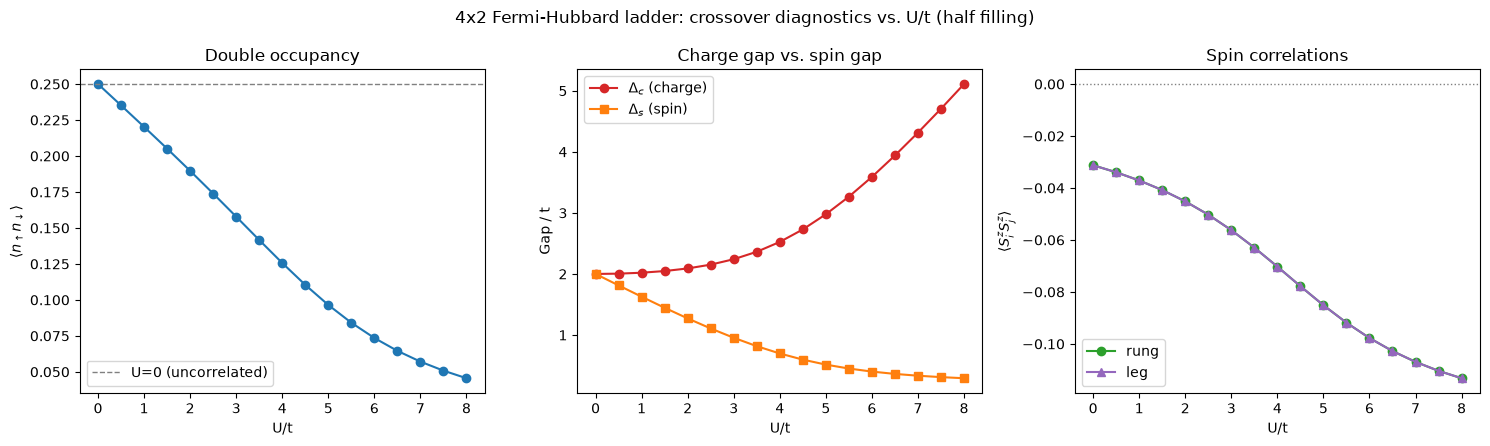

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(U_OVER_T_VALUES, fh2d_results["double_occ"], "o-", color="tab:blue")
axes[0].axhline(0.25, color="gray", ls="--", lw=1, label="U=0 (uncorrelated)")
axes[0].set_xlabel("U/t")
axes[0].set_ylabel(r"$\langle n_\uparrow n_\downarrow \rangle$")
axes[0].set_title("Double occupancy")
axes[0].legend()

axes[1].plot(U_OVER_T_VALUES, fh2d_results["charge_gap"], "o-", color="tab:red", label=r"$\Delta_c$ (charge)")
axes[1].plot(U_OVER_T_VALUES, fh2d_results["spin_gap"], "s-", color="tab:orange", label=r"$\Delta_s$ (spin)")
axes[1].set_xlabel("U/t")
axes[1].set_ylabel("Gap / t")
axes[1].set_title("Charge gap vs. spin gap")
axes[1].legend()

axes[2].plot(U_OVER_T_VALUES, fh2d_results["rung_corr"], "o-", color="tab:green", label="rung")
axes[2].plot(U_OVER_T_VALUES, fh2d_results["leg_corr"], "^-", color="tab:purple", label="leg")
axes[2].axhline(0.0, color="gray", ls=":", lw=1)
axes[2].set_xlabel("U/t")
axes[2].set_ylabel(r"$\langle S^z_i S^z_j \rangle$")
axes[2].set_title("Spin correlations")
axes[2].legend()

fig.suptitle("4x2 Fermi-Hubbard ladder: crossover diagnostics vs. U/t (half filling)")
fig.tight_layout()
fig.savefig("fermi_hubbard_2d_phase_diagram.png", dpi=150, bbox_inches="tight")
plt.show()